In [9]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import joblib
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator, array_to_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from PIL import Image
%matplotlib inline

In [10]:
TRAINING_PATH = "./Crop-Brain-MRI/"
TESTING_PATH = "./Test-Data/"

In [11]:
training_images = []
training_labels = []
test_images = []
test_labels = []

**Data Preparing**

In [12]:
for i in os.listdir(TRAINING_PATH):
  class_name = i
  class_path = os.path.join(TRAINING_PATH, class_name)
  for j in os.listdir(class_path):
    img_path = os.path.join(class_path, j)
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (256,256))
    training_images.append(img_resized)
    training_labels.append(class_name)

for i in os.listdir(TESTING_PATH):
  class_name = i
  class_path = os.path.join(TESTING_PATH, class_name)
  for j in os.listdir(class_path):
    img_path = os.path.join(class_path, j)
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (256,256))
    test_images.append(img_resized)
    test_labels.append(class_name)

In [13]:
training_images = np.array(training_images)
training_labels = np.array(training_labels)
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [14]:
print(training_images.shape)
print(training_labels.shape)

(8582, 256, 256, 3)
(8582,)


In [15]:
# normalize image
training_images = training_images / 255.0

In [16]:
test_images = test_images / 255.0

In [18]:
# Train-Test Split
x_train, x_val, y_train, y_val = train_test_split(training_images, training_labels, test_size=0.3, random_state=42) 
x_test, y_test = test_images, test_labels

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit_transform(y_val) 
y_test = le.fit_transform(y_test)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=4)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=4)

In [21]:
del training_images
del training_labels
del test_images
del test_labels

## Modelling

In [22]:
inception_resnetv2 = tf.keras.applications.InceptionResNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(256,256,3),
    pooling="avg",
    classes=4,
)

In [23]:
for layer in inception_resnetv2.layers:
  layer.trainable = False

## Model Architect

In [24]:
model_3 = tf.keras.models.Sequential()
model_3.add(inception_resnetv2)

model_3.add(tf.keras.layers.Flatten())
model_3.add(tf.keras.layers.Dropout(0.4))
model_3.add(tf.keras.layers.Dense(256,activation="relu", kernel_initializer='he_uniform'))
model_3.add(tf.keras.layers.Dropout(0.4))
model_3.add(tf.keras.layers.Dense(4, activation="softmax"))

In [25]:
#compile model
model_3.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#define checkpoint
checkpoint = ModelCheckpoint('model.keras', 
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='auto',
                             verbose=1)

#early stopping
earlystop = EarlyStopping(monitor='val_accuracy',
                          patience=5,
                          mode='auto',
                          verbose=1)

#reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', 
                              factor = 0.3, 
                              patience = 2, 
                              min_delta = 0.001,
                              mode='auto',
                              verbose=1)

## Model Training

In [26]:
history = model_3.fit(
    x_train,
    y_train,
    batch_size = 32,
    validation_data = (x_val, y_val),
    epochs = 20,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.4283 - loss: 1.4748
Epoch 1: val_accuracy improved from -inf to 0.76427, saving model to model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.4289 - loss: 1.4730 - val_accuracy: 0.7643 - val_loss: 0.6309 - learning_rate: 1.0000e-04
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.6843 - loss: 0.8062
Epoch 2: val_accuracy improved from 0.76427 to 0.80233, saving model to model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.6844 - loss: 0.8059 - val_accuracy: 0.8023 - val_loss: 0.5476 - learning_rate: 1.0000e-04
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.7341 - loss: 0.6726
Epoch 3: val_accuracy improved from 0.80233 to 0.81825, saving model to model.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.7342 - loss: 0.6725 - val_accuracy: 0.8183 - val_loss: 0.4912 - learning_rate: 1.0000e-04
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/

## Model Evaluation

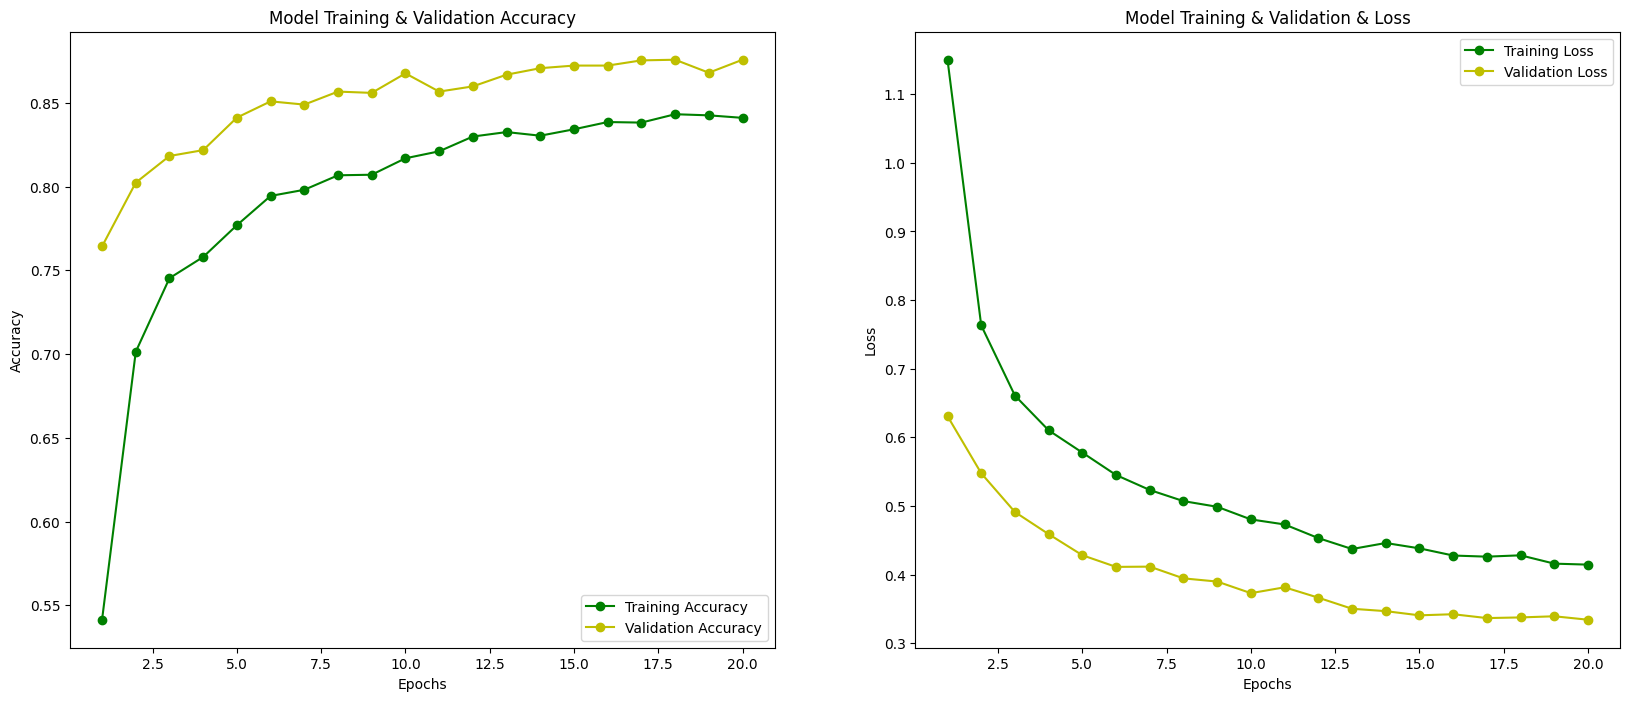

In [27]:
fig , ax = plt.subplots(1,2)
fig.set_size_inches(20, 8)

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

ax[0].plot(epochs , train_acc , 'g-o' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'y-o' , label = 'Validation Accuracy')
ax[0].set_title('Model Training & Validation Accuracy')
ax[0].legend(loc = 'lower right')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'y-o' , label = 'Validation Loss')
ax[1].set_title('Model Training & Validation & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

plt.show()

In [28]:
model_3.evaluate(x_val, y_val)

81/81 ━━━━━━━━━━━━━━━━━━━━ 74s 890ms/step - accuracy: 0.8720 - loss: 0.3468


[0.3342258930206299, 0.8757281303405762]

In [30]:
y_hat_val = model_3.predict(x_val)

81/81 ━━━━━━━━━━━━━━━━━━━━ 74s 910ms/step


In [31]:
y_hat_test = model_3.predict(x_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 898ms/step


In [32]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion Matrix',
                          cmap = plt.cm.Blues):
    
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    plt.grid(False)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 fontsize = 12,
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

[[556  99   2  17]
 [ 22 474  13  90]
 [  5  25 555  15]
 [  9  17   6 670]]


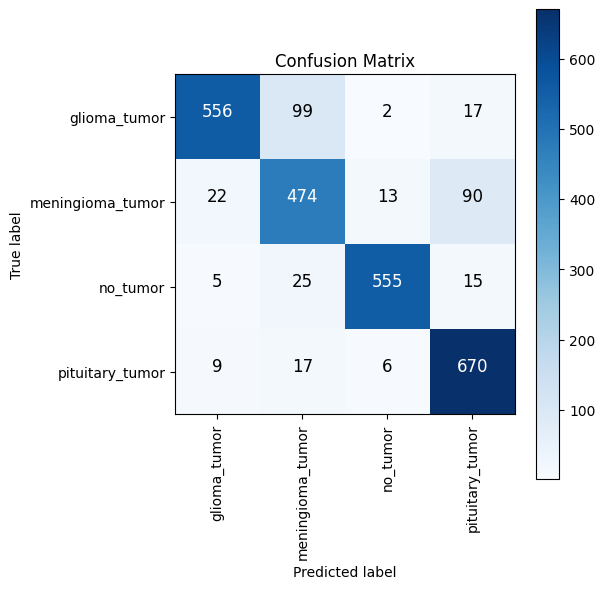

In [42]:
#evaluation on val
y_val_classes = np.argmax(y_val, axis=1)
y_hat_val_classes = np.argmax(y_hat_val, axis=1)
cm_val = confusion_matrix(y_val_classes, y_hat_val_classes)
print(cm_val)

#plot
plot_confusion_matrix(cm_val, ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"], normalize=False)

In [46]:
#get val classification report
print(classification_report(y_val_classes, y_hat_val_classes))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88       674
           1       0.77      0.79      0.78       599
           2       0.96      0.93      0.94       600
           3       0.85      0.95      0.90       702

    accuracy                           0.88      2575
   macro avg       0.88      0.87      0.88      2575
weighted avg       0.88      0.88      0.88      2575



[[258 105  20  17]
 [ 21 317  38  45]
 [  8  31 459  12]
 [  9  16  13 336]]


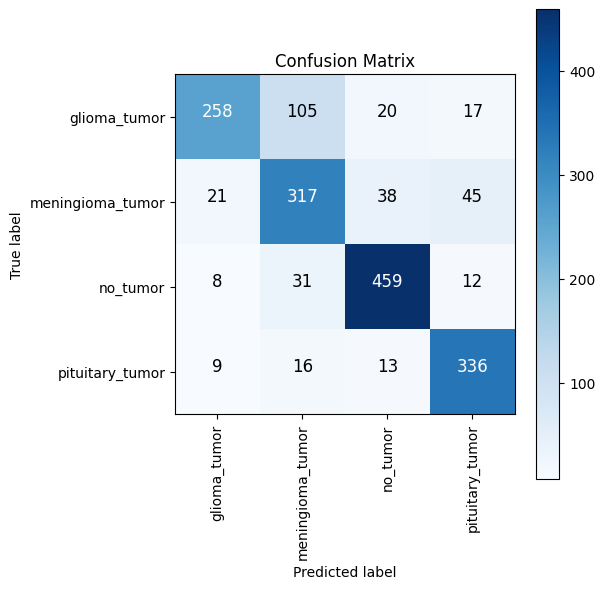

In [43]:
#evaluation on val
y_test_classes = np.argmax(y_test, axis=1)
y_hat_test_classes = np.argmax(y_hat_test, axis=1)
cm_test = confusion_matrix(y_test_classes, y_hat_test_classes)
print(cm_test)

#plot
plot_confusion_matrix(cm_test, ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"], normalize=False)

In [48]:
#get val classification report
print(classification_report(y_test_classes, y_hat_test_classes))

              precision    recall  f1-score   support

           0       0.87      0.65      0.74       400
           1       0.68      0.75      0.71       421
           2       0.87      0.90      0.88       510
           3       0.82      0.90      0.86       374

    accuracy                           0.80      1705
   macro avg       0.81      0.80      0.80      1705
weighted avg       0.81      0.80      0.80      1705

